In [1]:
import sys
from pathlib import Path

project_root = Path.cwd().parent.parent
if str(project_root) not in sys.path:
  sys.path.insert(0, str(project_root))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import datetime as dt
from datetime import timedelta

In [36]:
def load_trades(csv_path: str, start_date: str = "2022-04-01") -> pd.DataFrame:
    """
    Load and summarize trade data from CSV export.

    Args:
        csv_path: Path to the trades CSV.
        start_date: Ignore trades with entry timestamps before this date (UTC).

    Returns:
        DataFrame with columns [entry_time, exit_time, pnl, fees, total_pnl] that
        aggregates all legs belonging to the same trade. The total PnL is the sum
        of the P&L column minus the summed fees for the trade.
    """

    data = pd.read_csv(csv_path, header=0, skipinitialspace=True)
    if "Order Ids" in data.columns:
        data = data.drop(columns=["Order Ids"])

    for column in ("Entry Time", "Exit Time"):
        data[column] = pd.to_datetime(data[column], utc=True)

    cutoff = pd.Timestamp(start_date, tz="UTC")
    data = data[data["Entry Time"] >= cutoff].reset_index(drop=True)

    for column in ("Entry Time", "Exit Time"):
        data[column] = data[column].dt.tz_convert("America/New_York")

    grouped = (
        data.sort_values("Entry Time")
        .groupby(["Entry Time", "Exit Time"], as_index=False)
        .agg(pnl=("P&L", "sum"), fees=("Fees", "sum"))
    )

    grouped["total_pnl"] = grouped["pnl"] - grouped["fees"]
    grouped = grouped.rename(
        columns={
            "Entry Time": "entry_time", 
            "Exit Time": "exit_time"
        }
    )

    return grouped

In [39]:
spx_7dte_fe_trades = load_trades("../data/spx_7dte_forced_exit_trades.csv", start_date='2020-01-01')
spx_7dte_fe_trades['date'] = spx_7dte_fe_trades['entry_time'].dt.date
spx_7dte_fe_trades['fees'] = 5
spx_7dte_fe_trades.shape

(281, 6)

In [45]:
c = 50_000 + spx_7dte_fe_trades['total_pnl'].cumsum()

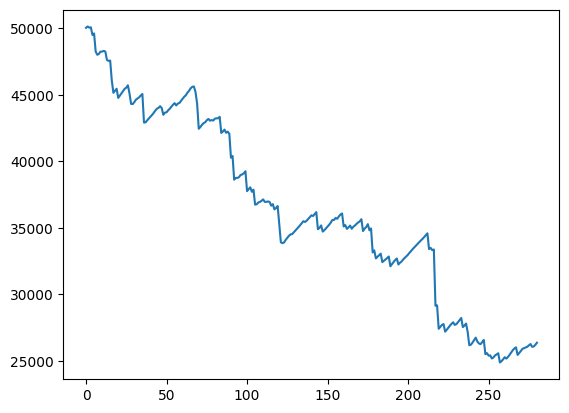

In [47]:
ax = c.plot()

In [ ]:
baseline_curve["equity_total_pnl"] = INITIAL_CAPITAL + baseline_curve["total_pnl"].cumsum()
baseline_curve["drawdown_pnl"] = (
    baseline_curve["equity_pnl"] / baseline_curve["equity_pnl"].cummax() - 1.0
)

<Axes: >

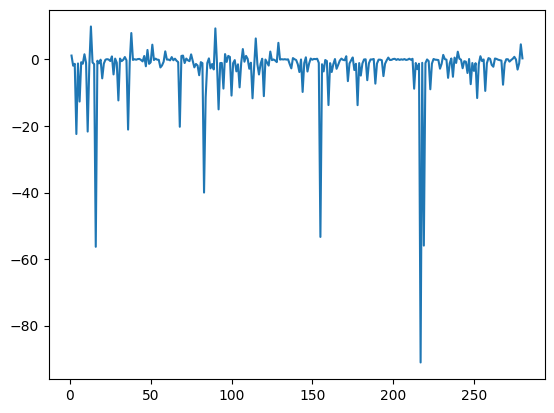

In [44]:
ax = spx_7dte_fe_trades['total_pnl'].pct_change().plot()

In [43]:
spx_7dte_fe_trades.head(50)

,entry_time,exit_time,pnl,fees,total_pnl,date
0,2020-01-07 15:50:00-05:00,2020-01-13 10:00:00-05:00,55,5,47,2020-01-07
1,2020-01-13 15:50:00-05:00,2020-01-21 10:00:00-05:00,110,5,102,2020-01-13
2,2020-01-23 15:50:00-05:00,2020-01-29 10:00:00-05:00,-80,5,-88,2020-01-23
3,2020-01-29 15:50:00-05:00,2020-02-03 10:00:00-05:00,35,5,27,2020-01-29
4,2020-02-03 15:50:00-05:00,2020-02-10 10:00:00-05:00,-570,5,-578,2020-02-03
5,2020-02-10 15:50:00-05:00,2020-02-18 10:00:00-05:00,125,5,117,2020-02-10
6,2020-02-19 15:50:00-05:00,2020-02-24 10:00:00-05:00,-1355,5,-1363,2020-02-19
7,2020-03-05 15:50:00-05:00,2020-03-11 10:00:00-04:00,-235,5,-243,2020-03-05
8,2020-03-24 15:50:00-04:00,2020-03-30 10:00:00-04:00,75,5,67,2020-03-24
9,2020-03-30 15:50:00-04:00,2020-04-06 10:00:00-04:00,180,5,172,2020-03-30


In [42]:
spx_7dte_fe_trades[spx_7dte_fe_trades['total_pnl'] < 0.0].shape

(76, 6)

In [41]:
spx_7dte_fe_trades[spx_7dte_fe_trades['total_pnl'] > 0.0].shape

(205, 6)

In [37]:
spx_7dte_trades = load_trades("../data/spx_7dte_no_constraints_trades.csv", start_date='2018-01-07')
spx_7dte_trades['date'] = spx_7dte_trades['entry_time'].dt.date
spx_7dte_trades['fees'] = 5
spx_7dte_trades.shape

(296, 6)

In [38]:
spx_7dte_trades.sort_values('date', ascending=True).head(30)

,entry_time,exit_time,pnl,fees,total_pnl,date
0,2018-01-17 15:50:00-05:00,2018-01-25 01:00:00-05:00,110,5,106,2018-01-17
1,2018-01-29 15:50:00-05:00,2018-02-06 01:00:00-05:00,120,5,116,2018-01-29
2,2018-02-12 15:50:00-05:00,2018-02-21 01:00:00-05:00,115,5,111,2018-02-12
3,2018-02-21 15:50:00-05:00,2018-03-01 01:00:00-05:00,120,5,116,2018-02-21
4,2018-03-05 15:50:00-05:00,2018-03-13 01:00:00-04:00,145,5,141,2018-03-05
5,2018-03-16 15:50:00-04:00,2018-03-24 01:00:00-04:00,130,5,126,2018-03-16
6,2018-03-26 15:50:00-04:00,2018-04-03 01:00:00-04:00,130,5,126,2018-03-26
7,2018-04-05 15:50:00-04:00,2018-04-14 01:00:00-04:00,170,5,166,2018-04-05
8,2018-04-16 15:50:00-04:00,2018-04-24 01:00:00-04:00,125,5,121,2018-04-16
9,2018-04-30 15:50:00-04:00,2018-05-08 01:00:00-04:00,140,5,136,2018-04-30


In [35]:
spx_7dte_trades[spx_7dte_trades['total_pnl'] < 0.0]

,entry_time,exit_time,pnl,fees,total_pnl,date
2,2018-01-29 15:50:00-05:00,2018-02-06 01:00:00-05:00,-85,5,-88,2018-01-29
72,2020-02-19 15:50:00-05:00,2020-02-27 01:00:00-05:00,-165,5,-168,2020-02-19
74,2020-03-05 15:50:00-05:00,2020-03-14 01:00:00-04:00,-1125,5,-1128,2020-03-05


<Axes: >

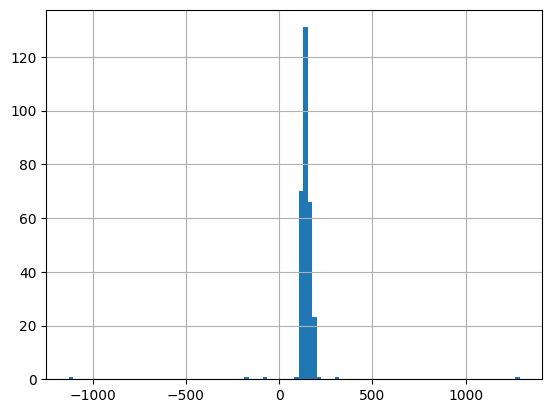

In [31]:
spx_7dte_trades['total_pnl'].hist(bins=100)

In [6]:
spx_1dte_trades = load_trades("../data/spx_1dte_no_constraints_trades.csv", start_date='')
spx_1dte_trades['date'] = spx_1dte_trades['entry_time'].dt.date
spx_1dte_trades['fees'] = 5

In [8]:
spx_1dte_trades[spx_1dte_trades['pnl'] > 0].

,entry_time,exit_time,pnl,fees,total_pnl,date
0,2022-04-01 15:50:00-04:00,2022-04-05 01:00:00-04:00,130,5,126,2022-04-01
1,2022-04-05 15:50:00-04:00,2022-04-07 01:00:00-04:00,120,5,116,2022-04-05
2,2022-04-07 15:50:00-04:00,2022-04-09 01:00:00-04:00,135,5,131,2022-04-07
3,2022-04-12 15:50:00-04:00,2022-04-14 01:00:00-04:00,110,5,106,2022-04-12
4,2022-04-14 15:50:00-04:00,2022-04-19 01:00:00-04:00,125,5,121,2022-04-14
...,...,...,...,...,...,...
412,2025-12-08 15:50:00-05:00,2025-12-10 01:00:00-05:00,145,5,141,2025-12-08
413,2025-12-10 15:50:00-05:00,2025-12-12 01:00:00-05:00,135,5,131,2025-12-10
414,2025-12-12 15:50:00-05:00,2025-12-16 01:00:00-05:00,140,5,136,2025-12-12
415,2025-12-16 15:50:00-05:00,2025-12-18 01:00:00-05:00,135,5,131,2025-12-16
